In [31]:
import numpy as np
import pandas as pd
import os
import sys
import glob
from sklearn.metrics import classification_report, recall_score
import tqdm
import re
import ast
from typing import List
import matplotlib.pyplot as plt
os.chdir("/data/resources/weichel-llama3/work/projects/nace_classification/nace_report_topic_analysis")
sys.path.append("../../benchmark")
import test_base
from sentence_splitter import split_text_into_sentences
from BERT_classifier.Classify_report_with_BERT import classification_report_BERT
from transformers import AutoModelForSequenceClassification, AutoTokenizer

In [32]:
sentence_length = 6

## Test using a BERT-Classification Model trained on paragraphs to classify an entire report.

**Function:** pdf -> NACE Class

In [33]:
dataset_path = "data/datasets/german_annual_reports"
dataset_path = "data/datasets/stoxx_600_extended"
dataset_path = "data/datasets/reports_subset_from_full_data_1"
dataset_path = "data/datasets/stoxx_600"

In [34]:
over_view_df_path = os.path.join(dataset_path, os.path.basename(dataset_path) + "_overview.csv")

dataset_path_texts = os.path.join(dataset_path, "TXTs")

dataset_name = os.path.basename(dataset_path)

In [56]:
results_path = "results/BERT_classification/dataset__stoxx_600_sentence_len_6__nace_level_1"
results_path = "results/BERT_classification/2_dataset__reports_subset_from_full_data_1_sentence_len_6__nace_level_1"
results_path = "results/BERT_classification/test_1_dataset__stoxx_600_sentence_len_6__nace_level_1"
reports_results = glob.glob(results_path+ "/*/*.csv")
len(reports_results)

226

In [57]:
nace_classes = pd.read_csv(over_view_df_path, index_col=0, sep=",")
nace_classes.head()

,Name,Symbol,FactSet ID,Revenue - 2022 (in EUR),Revenue - 2023 (in EUR),Revenue - 2024 (in EUR),NACE,NACE_letter,Report
0,SalMar ASA,SALM-NO,SALM-NO,1984.965581,2458.824022,2271.61166349053,3.21,A,salmar-annual-report-2022.pdf
1,Bakkafrost P/F,BAKKA-NO,BAKKA-NO,929.503079,937.862170,973.053513491168,3.21,A,Bakkafrost PF2.pdf
2,Antofagasta plc,ANTO-GB,ANTO-GB,5577.681426,5849.975673,6113.94698310345,7.29,B,Antofagasta plc1.pdf
3,Anglo American plc,AAL-GB,AAL-GB,33423.271144,28355.894415,25288.1884924262,7.29,B,Anglo American plc1.pdf
4,TotalEnergies SE,TTE-FR,TTE-FR,250538.948328,202517.658053,180837.266896225,6.10,B,Totalenergies EP Gabon1.pdf


In [58]:
report_to_nace_class = nace_classes.dropna(subset=["Report"]).set_index('Report').to_dict()["NACE"]
report_to_nace_class = {report[0][:-4] + ".txt": report[1] for report in report_to_nace_class.items()}
len(report_to_nace_class)

294

In [59]:
reports_path = glob.glob(os.path.join(dataset_path_texts, "*.txt"))
len(reports_path)

263

In [60]:
def get_tables(lines: list): 
    tables = []
    current_table = []

    for line in lines:
        if line.strip().startswith("|"):  # line belongs to a table
            current_table.append(line.strip())
        else:
            if current_table:  # table ended
                tables.append("\n".join(current_table))
                current_table = []

    # catch last table if file ends without empty lines
    if current_table:
        tables.append("\n".join(current_table))

    return tables

def preprocess_report(pdf_path: str) -> List[str]:

    with open(pdf_path, "r") as f: 
        text = f.read()
    
    lines = text.split("\n")

    tables = get_tables(lines)

    # drop if condidtion is True
    conditions = [
        # filter images
        lambda line: line == '<!-- image -->',
        
        #filter tables 
        lambda line: (line[0] == "|" and line[-1] == "|") if len(line) > 1 else False, 

        # filter headers
        lambda line: line.strip()[0] == "#" if len(line) > 0 else True,

        # filter sentences
        lambda line: "." not in line,
        
        # more than 50% is numbers
        lambda line: sum(ch.isalpha() for ch in line) / len(line) < 0.5,

        # minimum 3 words 
        lambda line: len(re.sub(r"[^a-zA-ZäöüÄÖÜß\s]", '', line).strip().split(" ")) < 3,

        # Minimum 2 Sentences
        #lambda line: sum([0 if len(sentence.split(" ")) < 3 else 1 for sentence in split_text_into_sentences(line, "en")]) < 2

    ]
    accepted_lines = [line for line in lines if not any(condition(line) for condition in conditions)]
    accepted_lines += tables

    chunks = []

    for line in accepted_lines: 
        sentences = split_text_into_sentences(line, language='en')
        sentences = [sentence.strip() for sentence in sentences]
        sentences = [sentence for sentence in sentences if sentence != ""]
        new_chunks = [(" ".join(sentences[i:i+sentence_length])).strip() for i in range(0, len(sentences), 3)]

        chunks += new_chunks

    # if there is only one sentence in the last chunk, balance the two last chunks
    if len(split_text_into_sentences(chunks[-1], language = "en")) == 1: 
        last_two_chunks = chunks[-2] + " " + chunks[-1]
        chunks[-2] = last_two_chunks[0:(len(last_two_chunks) + 1) // 2]
        chunks[-1] = last_two_chunks[(len(last_two_chunks) + 1) // 2: (len(last_two_chunks)) - (len(last_two_chunks) + 1) // 2]

    chunks = [re.sub(r'\b\d+\.\d+\b', '', chunk) for chunk in chunks]
    chunks = [re.sub(r"[^a-zA-ZäöüÄÖÜß.\s]", '', chunk) for chunk in chunks]
    chunks = [re.sub(r"\s+", " ", chunk) for chunk in chunks]
    chunks = [re.sub(r'\.{2,}', " ", chunk) for chunk in chunks]
    chunks = [re.sub(r'^\d+\.\s*', " ", chunk) for chunk in chunks]
    chunks = [chunk.lower() for chunk in chunks]
    chunks = [chunk.strip() for chunk in chunks]

    return chunks

In [61]:
ckpt = "results/BERT_models/results_null_classifiers__cos_thres_0.5__bert-base-uncased__train_full_model__some_labels/checkpoint-2331"
ckpt = "results/BERT_models/results__new_approach_data__num_layers_2bert-base-uncased__train_full_model__some_labels/checkpoint-15990"
model = classification_report_BERT.load_custom_bert_from_checkpoint(ckpt_path=ckpt)
tokenizer = AutoTokenizer.from_pretrained(ckpt)

In [62]:
import numpy as np
import pandas as pd

# assume df is your dataframe
def softmax(x):
    e = np.exp(x - np.max(x))   # subtract max for numerical stability
    return e / e.sum()

In [63]:
def majority_vote(df: pd.DataFrame, scores: list, threshold: float = 0) -> dict:
    
    df["max_class_sim"] = [scores[i] for i in np.argmax(df[scores], 1)]
    df["max_sim"] = df[scores].max(1)
    df = df[df["max_sim"] > threshold]
    evaluation = (df["max_class_sim"].value_counts() / len(df)).sort_values(ascending=False).to_dict()

    return evaluation

In [64]:
def confidence_weighted_voting(df: pd.DataFrame, scores: list, threshold: float = 0) -> dict:

    df["max_class_sim"] = [scores[i] for i in np.argmax(df[scores], 1)]
    df["max_sim"] = df[scores].max(1)
    df = df[df["max_sim"] > threshold]
    evaluation = (df.groupby("max_class_sim")["max_sim"].sum().sort_values(ascending=False)/len(df)).to_dict()

    return evaluation

In [65]:
def logit_stacking(df: pd.DataFrame, scores: list, threshold: float = 0) -> dict:

    df["max_sim"] = df[scores].max(1)
    df = df[df["max_sim"] > threshold]

    stacked = df[scores].sum(0)
    
    evaluation = stacked.to_dict()

    return evaluation

In [66]:
#reports_results = ['../../results/BERT_classification/test_1/Heritage Foods Limited1.txt/Heritage Foods Limited1.txt_classifications.csv']

In [67]:
def mean_reciprocal_rank(position_levels):
    """
    Compute Mean Reciprocal Rank (MRR)
    position_levels: list or array of integer ranks (0 = correct, 1 = 2nd, ...)
    """
    ranks = np.array(position_levels) + 1  # convert 0-based to 1-based ranks
    reciprocal_ranks = 1 / ranks
    return np.mean(reciprocal_ranks)

def recall_score(y_true, y_pred):
    y_true_bin = (np.array(y_true) == 0).astype(int)
    y_pred_bin = (np.array(y_pred) == 0).astype(int)
    tp = np.sum((y_true_bin == 1) & (y_pred_bin == 1))
    fn = np.sum((y_true_bin == 1) & (y_pred_bin == 0))
    return tp / (tp + fn) if (tp + fn) > 0 else 0.0


def precision_score(y_true, y_pred):
    y_true_bin = (np.array(y_true) == 0).astype(int)
    y_pred_bin = (np.array(y_pred) == 0).astype(int)
    tp = np.sum((y_true_bin == 1) & (y_pred_bin == 1))
    fp = np.sum((y_true_bin == 0) & (y_pred_bin == 1))
    return tp / (tp + fp) if (tp + fp) > 0 else 0.0


def accuracy_score(y_true, y_pred):
    y_true_bin = (np.array(y_true) == 0).astype(int)
    y_pred_bin = (np.array(y_pred) == 0).astype(int)
    return np.mean(y_true_bin == y_pred_bin)


def f1_score(y_true, y_pred):
    p = precision_score(y_true, y_pred)
    r = recall_score(y_true, y_pred)
    return (2 * p * r) / (p + r) if (p + r) > 0 else 0.0


def mean_reciprocal_rank(position_levels):
    ranks = np.array(position_levels) + 1  # convert 0-based to 1-based ranks
    reciprocal_ranks = 1 / ranks
    return np.mean(reciprocal_ranks)

In [68]:
confidence_weighted_voting.__name__

'confidence_weighted_voting'

In [69]:
reports_results

['results/BERT_classification/test_1_dataset__stoxx_600_sentence_len_6__nace_level_1/Hannover Rueck SE1.txt/Hannover Rueck SE1.txt_classifications.csv',
 'results/BERT_classification/test_1_dataset__stoxx_600_sentence_len_6__nace_level_1/Interpump Group S.p.A.1.txt/Interpump Group S.p.A.1.txt_classifications.csv',
 'results/BERT_classification/test_1_dataset__stoxx_600_sentence_len_6__nace_level_1/Intertek Group PLC1.txt/Intertek Group PLC1.txt_classifications.csv',
 'results/BERT_classification/test_1_dataset__stoxx_600_sentence_len_6__nace_level_1/Anheuser-Busch InBev SANV3.txt/Anheuser-Busch InBev SANV3.txt_classifications.csv',
 'results/BERT_classification/test_1_dataset__stoxx_600_sentence_len_6__nace_level_1/Scout24 SE3.txt/Scout24 SE3.txt_classifications.csv',
 'results/BERT_classification/test_1_dataset__stoxx_600_sentence_len_6__nace_level_1/Bridgepoint Group Plc1.txt/Bridgepoint Group Plc1.txt_classifications.csv',
 'results/BERT_classification/test_1_dataset__stoxx_600_sent

In [70]:
for agg_func in [confidence_weighted_voting, majority_vote, logit_stacking]: 
#for agg_func in [logit_stacking]: 
    
    print("--------")
    print()
    print(agg_func.__name__)
    print()
    print("--------")

    for conf in [0.9]:
        level = 1
        recording = [] 

        #if path_nace_code_descriptions is None: 
        path_nace_code_descriptions = "data/NACE_Rev2_Structure_Explanatory_Notes_EN__1_.tsv"
            
        df_nace_codes_descriptions = pd.read_csv(path_nace_code_descriptions, sep="\t")

        for results_path in tqdm.tqdm((reports_results)): 
        #for results_path in ((reports_results)): 

            report_name = os.path.basename(results_path.split("/")[-2])
            label = report_to_nace_class.get(report_name)

            level_1_label = test_base.get_all_level(label)[1]

            df_eval = pd.read_csv(results_path, index_col=0)
            scores = df_eval.columns.drop("Sentences")
            df_softmax = df_eval[scores].apply(softmax, axis=1)
            class_eval_dict = agg_func(
                df_softmax, scores, threshold=conf
            )

            # # get label of the report
            label = report_to_nace_class.get(os.path.basename(results_path).replace("_classifications.csv", ""))
            
            #print(os.path.basename(results_path))

            try: 
                if isinstance(label, float) or isinstance(label, int):                     
                    if len(str(label).split(".")[0]) == 1: 
                        label = "0" + str(label) 
                label_description = df_nace_codes_descriptions[df_nace_codes_descriptions["CODE"] == str(label)]["NAME"].iloc[0]
                evaluation = test_base.get_evaluation(class_eval_dict, label, df_nace_codes_descriptions, level)
            except IndexError: 
                label_description = ""
                evaluation = {}
            recording.append({"name": os.path.basename(results_path), "NACE": label, "label_description": label_description, **evaluation})
            df_recording = pd.DataFrame(recording)
            #df_recording.to_csv(os.path.join(result_path, "recordings.csv"))

        print()
        print("Treshold: ", conf)
        print("MRR: ", mean_reciprocal_rank(df_recording["position_lvl_1"].dropna()))
        df_recording = df_recording.dropna(subset=["nace_lvl_1", "first_class_1"])
        y_true = df_recording["nace_lvl_1"] 
        y_pred = df_recording["first_class_1"]
        print(classification_report(y_true, y_pred))

--------

confidence_weighted_voting

--------


100%|████████████████████████████████████████████████████████████████████████████████████████████████| 226/226 [03:26<00:00,  1.09it/s]
/data/resources/weichel-llama3/work/projects/nace_classification/nace_report_topic_analysis/nace_git/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/data/resources/weichel-llama3/work/projects/nace_classification/nace_report_topic_analysis/nace_git/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/data/resources/weichel-llama3/work/projec


Treshold:  0.9
MRR:  0.6364472937234132
              precision    recall  f1-score   support

           A       0.50      1.00      0.67         2
           B       0.60      0.75      0.67         4
           C       0.92      0.12      0.21        95
           D       0.38      0.89      0.53         9
           E       0.80      1.00      0.89         4
           F       0.43      0.60      0.50         5
           G       0.16      0.71      0.27        14
           H       0.36      0.80      0.50         5
           I       0.33      1.00      0.50         4
           J       0.00      0.00      0.00        12
           K       0.86      0.84      0.85        45
           L       1.00      1.00      1.00         9
           M       0.08      0.20      0.11         5
           N       0.14      0.17      0.15         6
           Q       0.00      0.00      0.00         1
           R       0.00      0.00      0.00         2
           S       0.00      0.00      0

100%|████████████████████████████████████████████████████████████████████████████████████████████████| 226/226 [03:27<00:00,  1.09it/s]
/data/resources/weichel-llama3/work/projects/nace_classification/nace_report_topic_analysis/nace_git/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/data/resources/weichel-llama3/work/projects/nace_classification/nace_report_topic_analysis/nace_git/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/data/resources/weichel-llama3/work/projec


Treshold:  0.9
MRR:  0.6369275417782881
              precision    recall  f1-score   support

           A       0.50      1.00      0.67         2
           B       0.60      0.75      0.67         4
           C       0.92      0.12      0.21        95
           D       0.38      0.89      0.53         9
           E       0.80      1.00      0.89         4
           F       0.43      0.60      0.50         5
           G       0.16      0.71      0.27        14
           H       0.36      0.80      0.50         5
           I       0.36      1.00      0.53         4
           J       0.00      0.00      0.00        12
           K       0.84      0.84      0.84        45
           L       1.00      1.00      1.00         9
           M       0.07      0.20      0.11         5
           N       0.17      0.17      0.17         6
           Q       0.00      0.00      0.00         1
           R       0.00      0.00      0.00         2
           S       0.00      0.00      0

100%|████████████████████████████████████████████████████████████████████████████████████████████████| 226/226 [03:28<00:00,  1.08it/s]


Treshold:  0.9
MRR:  0.587210018488299
              precision    recall  f1-score   support

           A       0.50      1.00      0.67         2
           B       0.60      0.75      0.67         4
           C       1.00      0.12      0.21        95
           D       0.38      0.89      0.53         9
           E       0.80      1.00      0.89         4
           F       0.43      0.60      0.50         5
           G       0.16      0.71      0.26        14
           H       0.36      0.80      0.50         5
           I       0.36      1.00      0.53         4
           J       0.00      0.00      0.00        12
           K       0.83      0.85      0.84        46
           L       1.00      1.00      1.00         9
           M       0.08      0.20      0.12         5
           N       0.17      0.17      0.17         6
           Q       0.00      0.00      0.00         1
           R       0.00      0.00      0.00         2
           S       0.00      0.00      0.


/data/resources/weichel-llama3/work/projects/nace_classification/nace_report_topic_analysis/nace_git/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/data/resources/weichel-llama3/work/projects/nace_classification/nace_report_topic_analysis/nace_git/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/data/resources/weichel-llama3/work/projects/nace_classification/nace_report_topic_analysis/nace_git/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: Undefi

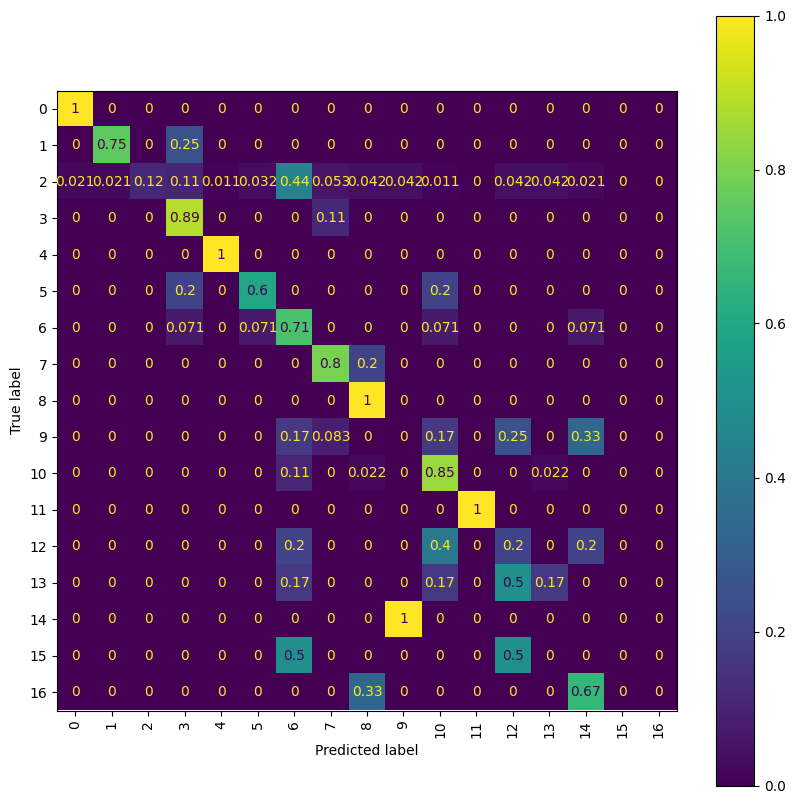

In [71]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_true, y_pred, normalize="true")
disp = ConfusionMatrixDisplay(confusion_matrix=cm)#, display_labels=list(label_mapping.keys()))
fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, xticks_rotation="vertical")
plt.show()


In [51]:
df_recording

,name,NACE,label_description,nace_lvl_1,position_lvl_1,classes_lvl_1,classification_lvl_1,first_class_1
0,Hannover Rueck SE1.txt_classifications.csv,65.11,Life insurance,K,0,16,{'K_FINANCIAL AND INSURANCE ACTIVITIES': 54.48...,K
1,Interpump Group S.p.A.1.txt_classifications.csv,28.12,Manufacture of fluid power equipment,C,1,16,{'G_WHOLESALE AND RETAIL TRADE; REPAIR OF MOTO...,G
2,Intertek Group PLC1.txt_classifications.csv,71.20,Technical testing and analysis,M,7,16,{'G_WHOLESALE AND RETAIL TRADE; REPAIR OF MOTO...,G
3,Anheuser-Busch InBev SANV3.txt_classifications...,11.05,Manufacture of beer,C,5,16,{'G_WHOLESALE AND RETAIL TRADE; REPAIR OF MOTO...,G


In [52]:
df_eval.max()

F                                                     7.785339
C                                                     9.262942
NO_CLASS                                              6.676576
M                                                      8.39411
L                                                     7.914007
H                                                     7.766338
P                                                     1.522799
G                                                     7.809256
D                                                     4.836526
J                                                     0.013062
Q                                                    10.218061
I                                                     9.519442
N                                                     8.963838
E                                                     8.321253
K                                                     6.946757
A                                                     8

In [53]:
df_softmax = df_eval[scores].apply(softmax, axis=1)
df_softmax.mean(0)

F           0.004892
C           0.009973
NO_CLASS    0.388152
M           0.008621
L           0.009537
H           0.010741
P           0.000773
G           0.176223
D           0.002392
J           0.000143
Q           0.010617
I           0.037118
N           0.035887
E           0.006711
K           0.296020
A           0.001826
B           0.000373
dtype: float64

In [54]:
df_softmax["max_class_sim"] = [scores[i] for i in np.argmax(df_softmax[scores], 1)]
df_softmax["max_sim"] = df_softmax[scores].max(1)
(df_softmax.groupby("max_class_sim")["max_sim"].sum().sort_values(ascending=False)/len(df_softmax)).to_dict()

{'NO_CLASS': 0.2778009452304876,
 'K': 0.24813591099360402,
 'G': 0.1484039767615166,
 'I': 0.03124355044883461,
 'N': 0.016747556337363117,
 'C': 0.009007457456684098,
 'Q': 0.008000503338222043,
 'H': 0.007632963595479091,
 'L': 0.007207321901084583,
 'M': 0.0071264222416487525,
 'E': 0.004978827608354013,
 'F': 0.0038360562519216537,
 'A': 0.001429122257625955,
 'D': 0.0011418118590629514}